## Librerias

In [1]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [12]:
# Cuantos partidos se jugaron?
partidos = len (mundial)
print(f"Se jugaron {partidos} partidos")
# Completar

Se jugaron 64 partidos


In [ ]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar

## Analisis

### Primera Parte

In [13]:
# Cuantas selecciones participaron?
selecciones = pd.concat([mundial["1"], mundial["2"]]).unique()
cantidad = len(selecciones)

print (f"Participaron {cantidad} selecciones")
print (selecciones)

Participaron 32 selecciones
['QATAR' 'ENGLAND' 'SENEGAL' 'UNITED STATES' 'ARGENTINA' 'DENMARK'
 'MEXICO' 'FRANCE' 'MOROCCO' 'GERMANY' 'SPAIN' 'BELGIUM' 'SWITZERLAND'
 'URUGUAY' 'PORTUGAL' 'BRAZIL' 'WALES' 'NETHERLANDS' 'TUNISIA' 'POLAND'
 'JAPAN' 'CROATIA' 'CAMEROON' 'KOREA REPUBLIC' 'ECUADOR' 'IRAN'
 'AUSTRALIA' 'SAUDI ARABIA' 'CANADA' 'COSTA RICA' 'GHANA' 'SERBIA']


In [8]:
# Cuantas fases tiene el mundial?

mundial["fase"] = mundial ["group"].apply(lambda x: "Fase de grupos" if "Group" in x else x)

print (len(mundial ["fase"].unique()))


6


In [15]:
# Cual fue la "attendance" promedio por partido?
mundial ["attendance"].mean()

53191.4375

In [6]:
# Cual fue el partido con mas diferencia de goles?
mundial["diferencia_goles"] = abs(mundial ["1_goals"] - mundial ["2_goals"])

partido = mundial.loc [mundial ["diferencia_goles"].idxmax()]
print (f"{partido['1']} vs {partido ['2']}: {partido ['diferencia_goles']:.0f} goles de diferencia")

SPAIN vs COSTA RICA: 7 goles de diferencia


In [22]:
# Cual es la selección que mas penales metió?
penales_1 = mundial.groupby ("1")["1_panelties_scored"].sum()
penales_2 = mundial.groupby ("2")["2_panelties_scored"].sum()

penales_totales = penales_1.add (penales_2, fill_value=0)

seleccion = penales_totales.idxmax()
cantidad = penales_totales.max()

print (seleccion, cantidad)


ARGENTINA 4


In [23]:
# Cual es la selección que mas penales le hicieron?
penales_recibidos_1 = mundial.groupby ("1")["1_panelties_scored"].sum()
penales_recibidos_2= mundial.groupby ("2")["2_panelties_scored"].sum()
penales_recibidos = penales_recibidos_1.add (penales_recibidos_2, fill_value=0)

seleccion = penales_recibidos.idxmax()
cantidad = penales_recibidos.max()

print (seleccion, cantidad)

ARGENTINA 4


### Segunda Parte

In [17]:
equipo : str = "ARGENTINA"

In [18]:
# Seleccionar todos los partidos que jugo el equipo de "local"


filtroLocal : pd.Series = mundial ["1"] == equipo
print (mundial [filtroLocal])

    match_no day_of_week       date   hour                  venue  \
4          5         Tue  22-Nov-22  11:00  Lusail Iconic Stadium   
23        24         Sat  26-Nov-22  20:00  Lusail Iconic Stadium   
49        50         Sat   3-Dec-22  20:00  Ahmed bin Ali Stadium   
60        61         Tue  13-Dec-22  20:00  Lusail Iconic Stadium   
63        64         Sun  18-Dec-22  16:00  Lusail Iconic Stadium   

             referee        group          1             2  attendance  ...  \
4      Slavko Vincic      Group C  ARGENTINA  SAUDI ARABIA       88012  ...   
23    Daniele Orsato      Group C  ARGENTINA        MEXICO       88966  ...   
49  Szymon Marciniak  Round of 16  ARGENTINA     AUSTRALIA       45032  ...   
60    Daniele Orsato   Semi-Final  ARGENTINA       CROATIA       88966  ...   
63  Szymon Marciniak        Final  ARGENTINA        FRANCE       88966  ...   

    1_panelties_scored  2_panelties_scored  1_goal_prevented  \
4                    1                   0    

In [ ]:
equipo : str = "ARGENTINA"
filtroVisitante : pd.Series = mundial["2"] == equipo
print(mundial[filtroVisitante])


    match_no day_of_week       date   hour                  venue  \
38        39         Wed  30-Nov-22  20:00  Lusail Iconic Stadium   
57        58         Fri   9-Dec-22  20:00  Lusail Iconic Stadium   

                referee          group            1          2  attendance  \
38       Michael Oliver        Group C       POLAND  ARGENTINA       84985   
57  Antonio Mateu Lahoz  Quarter-final  NETHERLANDS  ARGENTINA       88235   

    ...  1_panelties_scored  2_panelties_scored  1_goal_prevented  \
38  ...                   0                   0                25   
57  ...                   0                   1                15   

    2_goal_prevented  1_own_goal  2_own_goal 1_forced_turnovers  \
38                 4           0           0                 67   
57                 5           0           0                 91   

    2_forced_turnovers  1_defensive_pressure_applied  \
38                  48                           438   
57                  79             

In [ ]:
filtroLocal : pd.Series = mundial["1"] == equipo
filtroTotal : pd.Series = filtroLocal | filtroVisitante

partidos : pd.DataFrame = mundial[filtroTotal]
print(partidos)


    match_no day_of_week       date   hour                  venue  \
4          5         Tue  22-Nov-22  11:00  Lusail Iconic Stadium   
23        24         Sat  26-Nov-22  20:00  Lusail Iconic Stadium   
38        39         Wed  30-Nov-22  20:00  Lusail Iconic Stadium   
49        50         Sat   3-Dec-22  20:00  Ahmed bin Ali Stadium   
57        58         Fri   9-Dec-22  20:00  Lusail Iconic Stadium   
60        61         Tue  13-Dec-22  20:00  Lusail Iconic Stadium   
63        64         Sun  18-Dec-22  16:00  Lusail Iconic Stadium   

                referee          group            1             2  attendance  \
4         Slavko Vincic        Group C    ARGENTINA  SAUDI ARABIA       88012   
23       Daniele Orsato        Group C    ARGENTINA        MEXICO       88966   
38       Michael Oliver        Group C       POLAND     ARGENTINA       84985   
49     Szymon Marciniak    Round of 16    ARGENTINA     AUSTRALIA       45032   
57  Antonio Mateu Lahoz  Quarter-final  NE

In [19]:
goles_local = mundial.loc[filtroLocal, "1_goals"].sum()
goles_visitante = mundial.loc[filtroVisitante, "2_goals"].sum()
goles : int = goles_local + goles_visitante

print(goles)

15


In [17]:
# Cuantos goles hizo el equipo en promedio
promedio_goles = goles / len(partidos)
print(promedio_goles)

2.142857142857143


In [18]:
# Cuantos partidos gano el equipo
# Completar

ganados : int = ((mundial.loc[filtroLocal, "1_goals"] > mundial.loc[filtroLocal, "2_goals"]).sum() +
                 (mundial.loc[filtroVisitante, "2_goals"] > mundial.loc[filtroVisitante, "1_goals"]).sum())

print(ganados)

4


C:\Users\50049663\AppData\Local\Temp\ipykernel_13172\199438530.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  partidos["goles_equipo"] = partidos.loc[filtroLocal, "1_goals"].combine_first(partidos.loc[filtroVisitante, "2_goals"])


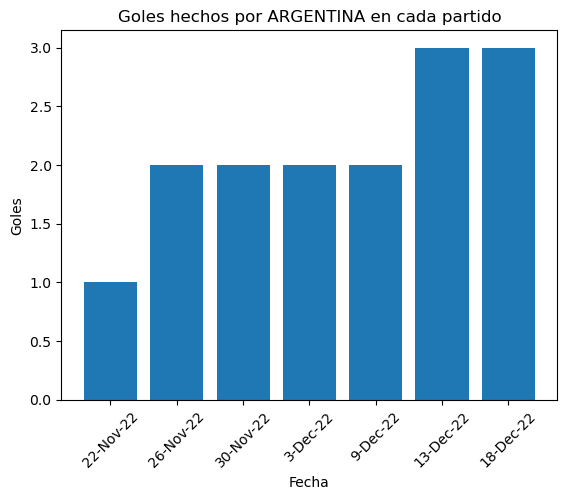

In [24]:
# Graficar los goles hechos por el equipo en cada partido

fig, ax = plt.subplots()
partidos["goles_equipo"] = partidos.loc[filtroLocal, "1_goals"].combine_first(partidos.loc[filtroVisitante, "2_goals"])
ax.bar(partidos["date"], partidos["goles_equipo"])
ax.set_title(f"Goles hechos por {equipo} en cada partido")
ax.set_xlabel("Fecha")
ax.set_ylabel("Goles")
plt.xticks(rotation=45)
plt.show()

### Tercera Parte

In [32]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar

equipos = pd.concat([mundial["1"], mundial["2"]]).unique()
goles = {equipo: mundial[mundial["1"] == equipo]["1_goals"].sum() + mundial[mundial["2"] == equipo]["2_goals"].sum() for equipo in equipos}

print(goles)

{'QATAR': 1, 'ENGLAND': 13, 'SENEGAL': 5, 'UNITED STATES': 3, 'ARGENTINA': 15, 'DENMARK': 1, 'MEXICO': 2, 'FRANCE': 16, 'MOROCCO': 6, 'GERMANY': 6, 'SPAIN': 9, 'BELGIUM': 1, 'SWITZERLAND': 5, 'URUGUAY': 2, 'PORTUGAL': 12, 'BRAZIL': 8, 'WALES': 1, 'NETHERLANDS': 10, 'TUNISIA': 1, 'POLAND': 3, 'JAPAN': 5, 'CROATIA': 8, 'CAMEROON': 4, 'KOREA REPUBLIC': 5, 'ECUADOR': 4, 'IRAN': 4, 'AUSTRALIA': 4, 'SAUDI ARABIA': 3, 'CANADA': 2, 'COSTA RICA': 3, 'GHANA': 5, 'SERBIA': 5}


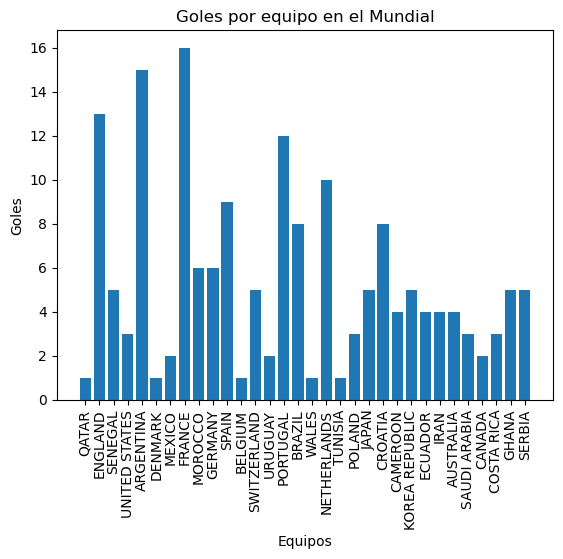

In [33]:
# Graficar los goles por equipo en todo el mundial

fig, ax = plt.subplots()
ax.bar(goles.keys(), goles.values())
ax.set_title("Goles por equipo en el Mundial")
ax.set_xlabel("Equipos")
ax.set_ylabel("Goles")
plt.xticks(rotation=90)
plt.show()

In [35]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar

equipo_max_goles = max(goles, key=goles.get)
cantidad_max_goles = goles[equipo_max_goles]

print(equipo_max_goles, cantidad_max_goles)

FRANCE 16


In [36]:
# Por cada partido, cual fue la diferencia de goles?
mundial["diferencia_goles"] = abs(mundial["1_goals"] - mundial["2_goals"])
mundial[["match_no", "1", "2", "diferencia_goles"]]

,match_no,1,2,diferencia_goles
0,1,QATAR,ECUADOR,2
1,2,ENGLAND,IRAN,4
2,3,SENEGAL,NETHERLANDS,2
3,4,UNITED STATES,WALES,0
4,5,ARGENTINA,SAUDI ARABIA,1
...,...,...,...,...
59,60,ENGLAND,FRANCE,1
60,61,ARGENTINA,CROATIA,3
61,62,FRANCE,MOROCCO,2
62,63,CROATIA,MOROCCO,1


In [37]:
# Por cada partido, cual fue el equipo que gano?
# Completar

mundial["ganador"] = mundial.apply(
    lambda row: row["1"] if row["1_goals"] > row["2_goals"] else (row["2"] if row["2_goals"] > row["1_goals"] else "Empate"),
    axis=1
)
mundial[["match_no", "1", "2", "ganador"]]

,match_no,1,2,ganador
0,1,QATAR,ECUADOR,ECUADOR
1,2,ENGLAND,IRAN,ENGLAND
2,3,SENEGAL,NETHERLANDS,NETHERLANDS
3,4,UNITED STATES,WALES,Empate
4,5,ARGENTINA,SAUDI ARABIA,SAUDI ARABIA
...,...,...,...,...
59,60,ENGLAND,FRANCE,FRANCE
60,61,ARGENTINA,CROATIA,ARGENTINA
61,62,FRANCE,MOROCCO,FRANCE
62,63,CROATIA,MOROCCO,CROATIA


In [ ]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?

mundial["fase"] = mundial["group"].apply(lambda x: "Fase de grupos" if "Group" in x else x)
goles_por_fase = mundial.groupby(["fase", "1"])["1_goals"].sum().add(
    mundial.groupby(["fase", "2"])["2_goals"].sum(), fill_value=0
)

equipos_max_goles = goles_por_fase.groupby("fase").idxmax()
goles_maximos = goles_por_fase.groupby("fase").max()

for fase, equipo in equipos_max_goles.items():
    print(f"En la {fase}, el equipo que hizo más goles fue {equipo} con {goles_maximos[fase]:.0f} goles.")

En la Fase de grupos, el equipo que hizo más goles fue ('Fase de grupos', 'SPAIN', 'GERMANY') con 13 goles.
En la Final, el equipo que hizo más goles fue ('Final', 'ARGENTINA', 'FRANCE') con 6 goles.
En la Play-off for third place, el equipo que hizo más goles fue ('Play-off for third place', 'CROATIA', 'MOROCCO') con 3 goles.
En la Quarter-final, el equipo que hizo más goles fue ('Quarter-final', 'NETHERLANDS', 'ARGENTINA') con 4 goles.
En la Round of 16, el equipo que hizo más goles fue ('Round of 16', 'PORTUGAL', 'AUSTRALIA') con 7 goles.
En la Semi-Final, el equipo que hizo más goles fue ('Semi-Final', 'ARGENTINA', 'CROATIA') con 3 goles.


### Tercera Parte

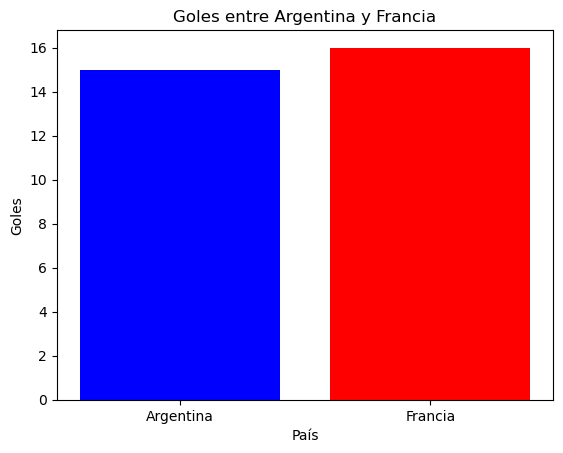

In [ ]:
goles_argentina = mundial[mundial["1"] == "ARGENTINA"]["1_goals"].sum() + mundial[mundial["2"] == "ARGENTINA"]["2_goals"].sum()
goles_francia = mundial[mundial["1"] == "FRANCE"]["1_goals"].sum() + mundial[mundial["2"] == "FRANCE"]["2_goals"].sum()

fig, ax = plt.subplots()
ax.bar(["Argentina", "Francia"], [goles_argentina, goles_francia], color=["blue", "red"])
ax.set_title("Goles entre Argentina y Francia")
ax.set_xlabel("País")
ax.set_ylabel("Goles")
plt.show()